In [1]:
import xclone
import scanpy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict

xclone.pp.efficiency_preview()
%load_ext autoreload
%autoreload 2

(Running XClone 0.3.8)
2025-07-23 05:26:31


/orfeo/cephfs/scratch/cdslab/ebusca00/envs/virtualenv/snv_caller/lib/python3.9/site-packages/xclone/preprocessing/_anno_data.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


[XClone efficiency] multiprocessing cpu total count in your device 48


## Import auxiliary functions

In [2]:
from aux_fns import *
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load read counts
Load variant read counts and depths from the XClone package.

In [3]:
labels_df = pd.read_csv("../data/BCH869_489_clone_id.tsv", sep="\t", header=None, names=["CellID", "CloneID"])

sample_names = pd.read_csv("../data/cellSNP.samples.tsv", sep="\t", header=None, names=["CellID"])
sample_names["CellID"] = sample_names["CellID"].map(lambda x: x.replace(".sort",""))
tokeep_cells = sample_names["CellID"].isin(labels_df["CellID"])

sample_names = sample_names.loc[sample_names["CellID"].isin(labels_df["CellID"])]

# reorder based on the cellID order in "sample_names"
labels_df = labels_df.set_index("CellID").reindex(sample_names.set_index("CellID").index).reset_index()
labels = labels_df.CloneID.tolist()
print(labels)

[1, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 2, 1, 2, 1, 1, 2, 2, 2, 1, 2, 1, 4, 2, 1, 2, 2, 1, 2, 1, 1, 1, 2, 2, 1, 2, 2, 1, 2, 2, 1, 2, 1, 1, 2, 2, 1, 1, 2, 1, 1, 2, 1, 2, 2, 1, 1, 1, 1, 2, 1, 2, 2, 2, 3, 1, 1, 2, 2, 2, 1, 2, 1, 3, 2, 2, 3, 2, 2, 1, 3, 2, 2, 1, 1, 2, 2, 1, 2, 2, 2, 1, 2, 1, 2, 2, 1, 1, 1, 2, 2, 2, 2, 1, 1, 1, 1, 2, 1, 3, 2, 1, 1, 1, 3, 2, 1, 2, 1, 1, 1, 3, 1, 2, 2, 1, 1, 2, 2, 2, 1, 1, 2, 2, 1, 2, 3, 2, 1, 3, 1, 2, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1, 1, 2, 2, 1, 2, 2, 1, 2, 3, 3, 1, 1, 2, 1, 2, 2, 1, 1, 1, 3, 1, 1, 2, 1, 1, 1, 1, 2, 1, 1, 3, 1, 2, 1, 1, 2, 1, 2, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 1, 1, 1, 2, 2, 2, 2, 1, 2, 2, 1, 2, 2, 2, 2, 2, 1, 2, 1, 1, 1, 1, 3, 1, 2, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 3, 1, 3, 1, 1, 1, 1, 4, 2, 2, 1, 2, 1, 2, 2, 2, 1, 3, 2, 2, 2, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 2, 4, 3, 1, 3, 2, 3, 2, 2, 1, 2, 3, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 3, 2, 1, 1, 2, 1, 2, 1, 3, 2, 4, 2, 1, 2, 1, 2, 2, 3, 1, 1, 1, 2, 2, 2, 1, 4, 2, 1, 1, 3, 1, 1, 

In [4]:
AD = scanpy.read_mtx("../data/cellSNP.tag.AD.mtx").X[:, tokeep_cells]
DP = scanpy.read_mtx("../data/cellSNP.tag.AD.mtx").X[:, tokeep_cells]
assert AD.shape == DP.shape
print(f"AD and DP shape: {AD.shape} and {DP.shape}")
assert AD.shape[1] == len(labels)

AD and DP shape: (59728, 489) and (59728, 489)


In [5]:
row_nnz = DP.getnnz(axis=1)  # non-zero count per row
nonzero_rows = row_nnz > 5
tokeep_muts = np.where(nonzero_rows)[0]

# n_muts = 100
# tokeep_muts = np.random.choice(tokeep_muts, size=n_muts, replace=False)
nonzero_rows = np.zeros_like(nonzero_rows, dtype=bool)
nonzero_rows[tokeep_muts] = True
AD = AD[nonzero_rows]
DP = DP[nonzero_rows]
assert AD.shape == DP.shape
print(f"AD and DP shape: {AD.shape} and {DP.shape}")

AD and DP shape: (35087, 489) and (35087, 489)


# Hierarchical clustering 

In [6]:
RDR_adata = xclone.data.bch869_rdr()
gene_expression = RDR_adata.layers["raw_expr"][tokeep_cells].transpose()

cell_ids = RDR_adata.obs["Sample"].index[tokeep_cells]
clone_ids = list(labels_df.set_index("CellID").reindex(cell_ids).reset_index()["CloneID"])

In [40]:
linkage_matrix = compute_linkage(gene_expression)

(489, 489)


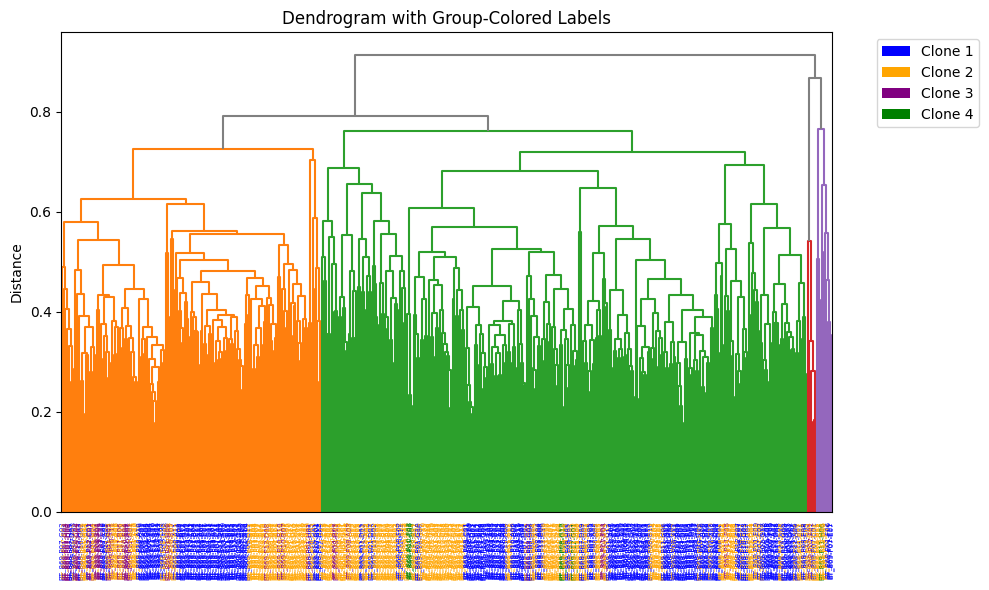

In [8]:
from matplotlib import colors as mcolors
from matplotlib.patches import Patch

unique_groups = set(clone_ids)
color_list = ["blue","orange","purple","green"]
color_map = {group: color_list[i % len(color_list)] for i, group in enumerate(unique_groups)}
label_colors = [color_map[group] for group in clone_ids]

plt.figure(figsize=(10, 6))
dendro = dendrogram(linkage_matrix, labels=cell_ids, color_threshold=0.78, above_threshold_color="grey")
leaf_order = dendro["leaves"]
groupings_ordered = np.array(clone_ids)[leaf_order]

ax = plt.gca()
xlbls = ax.get_xmajorticklabels()
for lbl, group in zip(xlbls, groupings_ordered):
    lbl.set_color(color_map[group])

legend_elements = [Patch(facecolor=color_map[g], label=f'Clone {g}') for g in unique_groups]

plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.2, 1))
plt.title('Dendrogram with Group-Colored Labels')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

In [9]:
N = linkage_matrix.shape[0] + 1
edges = []

for i, (child1, child2, dist, _) in enumerate(linkage_matrix):
    parent = N + i
    for child in (int(child1), int(child2)):
        if child < N:
            child_height = 0.0
        else:
            child_height = linkage_matrix[child - N, 2]
        branch_length = dist - child_height
        edges.append([str(parent), str(child), branch_length])

# Compute Ornstein-Uhlenbeck kernel

First define the edge matrix of the clone phylogeny and then compute the kernel.

In [10]:
# edges = [
#     ("M", "1", 1.),
#     ("M", "2", 1.),
#     ("2", "3", 1.),
#     ("2", "4", 1.),
# ]
# clone_labels = ["1", "2", "3", "4"]
# clone_labels = labels.astype("int").astype("str").values
clone_labels = [str(i) for i in range(gene_expression.shape[1])]

In [11]:
kernel = compute_ou_kernel(edges, clone_labels, lambd=0.5, sigma_squared=1.0)

assert kernel.shape[0] == kernel.shape[1] 
assert kernel.shape[0] == AD.shape[1]

print(f"OU Kernel Matrix of shape {kernel.shape}")
print(kernel)

OU Kernel Matrix of shape (489, 489)
[[1.         0.45307997 0.45307997 ... 0.45307997 0.45307997 0.53530859]
 [0.45307997 1.         0.46672734 ... 0.56439566 0.46672734 0.45307997]
 [0.45307997 0.46672734 1.         ... 0.46672734 0.6175495  0.45307997]
 ...
 [0.45307997 0.56439566 0.46672734 ... 1.         0.46672734 0.45307997]
 [0.45307997 0.46672734 0.6175495  ... 0.46672734 1.         0.45307997]
 [0.53530859 0.45307997 0.45307997 ... 0.45307997 0.45307997 1.        ]]


# Latent Gaussian Process with Binomial likelihood

In [12]:
# imports
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

from torch.autograd.functional import hessian  # compute the hessian matrix
# from scipy.special import gammaln  # to compute the binomial coefficient

In [13]:
device = torch.device("cuda")

In [14]:
device

device(type='cuda')

In [15]:
# convert to tensor the data
Y = torch.sparse_coo_tensor(AD.nonzero(), AD.data, AD.shape).to_dense().to(device=device)
D = torch.sparse_coo_tensor(DP.nonzero(), DP.data, DP.shape).to_dense().to(device=device)
Z = torch.tensor(labels, dtype=torch.int, device=device)

V, N = Y.shape  # #mutations x #cells
K = len(Z.unique())  # #clones

assert Y.shape[1] == D.shape[1]
assert Y.shape[1] == Z.shape[0]
print(f"{V} SNPs, {N} cells and {K} clones\n")

print(f"Devices\nY = {Y.device}\nD = {D.device}\nZ = {Z.device}")

/tmp/ipykernel_973255/847291216.py:2: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  Y = torch.sparse_coo_tensor(AD.nonzero(), AD.data, AD.shape).to_dense().to(device=device)


35087 SNPs, 489 cells and 4 clones

Devices
Y = cuda:0
D = cuda:0
Z = cuda:0


## Initialize the parameters
Initialize `\mu` and the optimizer.
Note the `requires_grad=True` meaning we are optimizing it.

In [16]:
mu = [torch.zeros(N, requires_grad=True, dtype=torch.float32, device=device) for _ in range(K)]

Sigma = torch.tensor(kernel, dtype=torch.float32, device=device)
Sigma_inv = torch.linalg.inv(Sigma)  # inverese of Sigma -> N x N
log_det_Sigma = torch.logdet(Sigma + 1e-6 * torch.eye(N, device=device))  # log of determinant of Sigma

print(f"Devices\nmu = {[mu_i.device for mu_i in mu]}\nSigma = {Sigma.device}\nSigma_inv = {Sigma_inv.device}\nlog_det_Sigma = {log_det_Sigma.device}")

Devices
mu = [device(type='cuda', index=0), device(type='cuda', index=0), device(type='cuda', index=0), device(type='cuda', index=0)]
Sigma = cuda:0
Sigma_inv = cuda:0
log_det_Sigma = cuda:0


## Optimization

In [17]:
import time

In [18]:
0.24 * V * K

33683.52

In [23]:
start_time = time.time()

optimizer = optim.Adam(mu, lr=1e-2)
for epoch in range(1):
    optimizer.zero_grad()  # reset the gradient

    gamma_store = torch.zeros((V, K, N))  # store all gammas
    total_laplace = 0.0
    for v in range(V):
        if v % 500 == 0:
            print(f"Processed {v} out of {V} mutations in {time.time() - start_time} seconds")
        for k in np.unique(Z.to("cpu")):
            # compute log p(y_v | d_v, mu_v, Sigma) with laplace approx
            y_v = Y[v, :]
            d_v = D[v, :]
            laplace_term, gamma_hat = compute_laplace_term(y_v, d_v, mu[k-1], Sigma_inv, Z, k)
            total_laplace += laplace_term
            gamma_store[v, k-1] = gamma_hat

    print(f"Devices\nlaplace_term = {laplace_term.device}\ngamma_hat = {gamma_hat.device}")

    loss = -total_laplace
    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch}: Loss = {loss.item():.3f}")

end_time = time.time()

Processed 0 out of 35087 mutations in 0.14148378372192383 seconds
Processed 500 out of 35087 mutations in 10.287839651107788 seconds
Processed 1000 out of 35087 mutations in 20.251075983047485 seconds
Processed 1500 out of 35087 mutations in 30.2017879486084 seconds
Processed 2000 out of 35087 mutations in 40.19826602935791 seconds
Processed 2500 out of 35087 mutations in 50.16171145439148 seconds
Processed 3000 out of 35087 mutations in 60.18011999130249 seconds
Processed 3500 out of 35087 mutations in 70.23398518562317 seconds
Processed 4000 out of 35087 mutations in 80.21789646148682 seconds
Processed 4500 out of 35087 mutations in 90.40527892112732 seconds
Processed 5000 out of 35087 mutations in 100.43634819984436 seconds
Processed 5500 out of 35087 mutations in 110.44448399543762 seconds
Processed 6000 out of 35087 mutations in 120.4589946269989 seconds
Processed 6500 out of 35087 mutations in 130.76044297218323 seconds
Processed 7000 out of 35087 mutations in 140.8582727909088 s

In [24]:
# 166s GPU (device = mps) with 100 mutations -> mac OS
# 22.8s CPU with 100 mutations -> mac OS
# 118s GPU (device = cuda) with 100 mutations -> Orfeo
end_time - start_time

734.2036588191986

## Assess results

In [25]:
VAF = Y / D
VAF[VAF.isnan()] = 0

/orfeo/cephfs/scratch/cdslab/ebusca00/envs/virtualenv/snv_caller/lib/python3.9/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


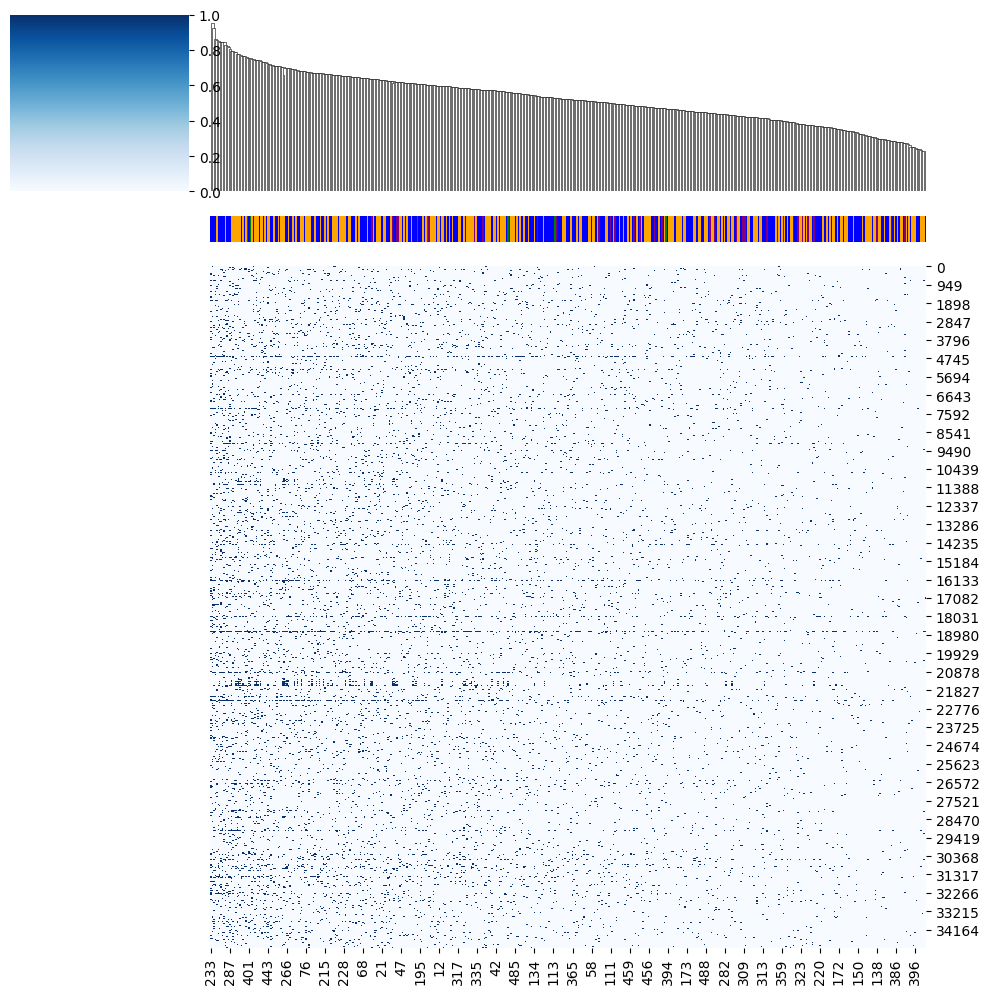

In [36]:
import seaborn as sns

sns.clustermap(VAF.cpu(), col_colors=[color_map[i] for i in clone_ids], col_cluster=True, row_cluster=False, cmap="Blues")

# leaf_order = dendro["leaves"]
# groupings_ordered = np.array(clone_ids)[leaf_order]

# ax = plt.gca()
# xlbls = ax.get_xmajorticklabels()
# for lbl, group in zip(xlbls, groupings_ordered):
#     lbl.set_color(color_map[group])

# legend_elements = [Patch(facecolor=color_map[g], label=f'Clone {g}') for g in unique_groups]

# plt.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.2, 1))
plt.tight_layout()
plt.show()